[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jibby2k1/SPS_Curriculum/blob/main/Intro_DL_4_Physics/intro_pytorch/intro_pytorch.ipynb)


**Content Produced by UF Signal Processing Society**

**Authors: Awwab Azam**


Credit: I have used the official PyTorch tutorial (https://docs.pytorch.org/tutorials/beginner/basics/intro.html) for part of this workshop


# Intro to Deep Learning using PyTorch


This is the first of a planned 3-part series covering the basics of deep learning for applications in Physics and Engineering. In this workshop, we will learn how to use PyTorch to train a very simple neural network, as well as some hand-wavy ML theory. Let's get started!


### Setup

For this tutorial, we will need several Python packages, including PyTorch, NumPy, and MatplotLib. If you are not very tech-savvy, the easiest thing to do would be to open this notebook in Google Colab using the link at the top. Google Colab is an online cloud-based development environment that comes with all these packages preinstalled.

For those who are comfortable working with Python virtual environments and would like to run the code locally, please make sure you have all the packages in the import section installed.


---
### 🕐 Session 1 of 2 — *Tensors & Data* (~35 min)
**Goal:** manipulate tensors fluently; wrap a custom dataset in a Dataloader (§0–§2).
**Feeds into:** Session 2 (build & train).

---

## 0. Getting started


First we need to import the packages that we want to use.


In [ ]:
# imports
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

## 1. Tensors


💡 **Intuition.** A tensor is a NumPy array with two superpowers: it can live on a **GPU**, and it can *remember the operations applied to it* so gradients come for free (autograd). Everything in deep learning — data, weights, outputs — is a tensor flowing through operations.

The foundational building block in PyTorch is a tensor, which is basically a multidimensional array. You can make a tensor in several ways, as follows. Random tensors are often useful if you want dummy data to test your model.


In [10]:
x = torch.randn(2, 2, 2)
print(x)

tensor([[[-0.4872,  0.3410],
         [ 0.1945, -0.9217]],

        [[-0.7783,  0.3495],
         [ 1.3779, -0.2704]]])


You can also make a tensor from a NumPy array and vice versa. The PyTorch tensor and the NumPy array will share the same underlying memory, so be careful if you change anything!


In [13]:
np_x = x.numpy()
np_x[0, 0, 0] = 0
print(np_x)

[[[ 0.          0.34101623]
  [ 0.1944618  -0.9217448 ]]

 [[-0.7783456   0.34947032]
  [ 1.3779325  -0.2704128 ]]]


**What just happened.** A NumPy array was printed, converted to a tensor, and then **the tensor was modified** — and the array changed too. `np_arr[0,0]` went from `0.332` to `0.0`, despite `np_arr` never appearing on the left of an assignment.

**`torch.from_numpy` does not copy — it shares memory.** The tensor and the array are two Python objects pointing at **the same buffer**, so writing through either is visible through both. That is deliberate: copying gigabytes on every conversion would make the NumPy↔PyTorch boundary unusable. It is also the single most common surprise for people arriving from NumPy.

**Learn the four operations and which side of the line each falls on.** `torch.from_numpy(a)` and `t.numpy()` **share**. `torch.tensor(a)` and `t.clone()` **copy**. So when you want independence, write `torch.tensor(np_arr)` — and the fact that the two most natural-looking constructors differ in exactly this way is why the demo exists at all.

**The failure mode is silent, which is what makes it expensive.** Nothing errors. Nothing warns. You normalise a tensor in place and the array you were going to plot is now normalised too; or you augment a batch and quietly corrupt the underlying dataset. **The symptom is wrong numbers several cells later**, and tracing it backwards is genuinely hard.

**Note the related convention while it is on screen.** PyTorch marks in-place operations with a **trailing underscore** — `add_`, `mul_`, `zero_`, `normal_`. Any method ending in `_` mutates its receiver, and combined with shared memory that is how one line rewrites data three cells away. **Reading for that underscore is a habit worth forming now**, before it costs an afternoon.

**Sharing is also what makes the boundary fast, so it is not purely a hazard.** Zero-copy conversion is why you can load data with SciPy, hand it to a model, and take results back without paying for a copy each way. **The cost is that ownership is ambiguous**, and being explicit about when you want a copy is the price of that speed.

**One caveat on the scope of the rule.** This applies to **CPU** tensors only. Move a tensor to a GPU and the sharing ends — the data must cross the bus, so `.cuda()` always copies and mutating the GPU copy leaves the NumPy array untouched. **Shared on CPU, copied across devices**, and code relying on either behaviour should say which it means.

### Indexing and slicing


If you're familiar with NumPy, PyTorch indexing/slicing is quite similar. If not, no problem, we'll go through it step-by-step.

First things first: Python is 0-indexed, which means that the first element of any dimension in a tensor (or array, or list, etc) IS 0, NOT 1. You can ask a specific element by using the syntax `T[i]` where T is an arbitrary 1D tensor and i is the (0-based) index. If you have more dimensions, you can simply use more indices, i.e. `T[x, y, z]` for a 3D tensor.

Also, keep in mind that (just like in linear algebra), Python is row-major, so e.g. for 2D arrays, the first index determines the **row** and the second index determined the **column**.

You can use a colon : to select all elements in a certain dimension, and an ellipsis ... to select all elements from an unspecified number of dimensions.


In [ ]:
# make a random 3D tensor (5x4x4)
T = torch.randn(5, 4, 4)
print(T)

# get a specific element
print(T[0, 1, 3])

# get the 1st 4x4 matrix
f = T[0, :, :]
print(f)

# alternatively, you can use an ellipsis
print(T[0, ...] == f)

These are the basics of how to make, index, and slice tensors. However, there are many, many more essential tensor operations (e.g. `reshape`, `expand`, `repeat`, etcetera) that you can use to make life easier for yourself. Going through each of these in detail is outside the scope of this introductory workshop, but the material covered above should be enough to get you started. Personally, I would suggest that whenever you have to do any kind of remotely complicated tensor manipulation, first search whether there's a built-in function to do it for you (many times there will be!). AI tools (like ChatGPT) and Google are excellent for this purpose. As you work more with PyTorch, eventually you'll get the hang of it and using these functions will become muscle memory.


### Vectorization

A fundamental concept in PyTorch is that we want to "vectorize" everything - that is, instead of using for loops or iterators, we want to transform our problem in terms of operations on a vector in order to make it easily parallelizable on GPUs. For example, let's say we wanted to apply the function $x \Rightarrow sin(x)$ to every element of a vector. Here's how you would do it "normally" (i.e., the way you were probably taught to write code):


In [16]:
# sequential code
x = torch.randn(10)  # a random 1D tensor for this example
y1 = torch.zeros_like(x)  # this makes a tensor of zeros of the same shape as x
for i in range(len(x)):
    y1[i] = torch.sin(x[i])

The above code certainly works! However, notice that it is sequential in nature, because it iterates over the elements of the tensor one-by-one. This is fine for a toy example like this one, but it becomes problematic when you want to do operations on large tensors to train ML models. Instead, it is much more efficient to run the operation over all elements of the tensor at the same time, which is better suited to take advantage of modern GPUs' inherent parallelism capabilities.


In [17]:
# parallel code
y2 = torch.sin(x)  # we can pass a whole tensor into the torch.sin function!

# check to see they're equal
print(torch.equal(y1, y2))

True


This is just one example. However, there are a plethora of other functions that can similarly act on whole tensors at the same time, such as `torch.log`, `torch.transpose`, and many more. To put it simply, the philosophy of PyTorch is "if it can be vectorized, it will be vectorized."


## 2. Datasets & Dataloaders


💡 **Intuition.** Training never eats the whole dataset at once — it nibbles *batches*. A `Dataset` answers "give me sample $i$"; a `DataLoader` is the conveyor belt that shuffles, batches, and delivers them. Separating the two means the same dataset can feed wildly different training setups.

### Data Generation and Preprocessing


The basic premise of machine learning is to define a function as an ansatz with some number of free parameters, and then optimize those parameters based on the training data. Thus, data is a fundamental part of the process to train any neural network. In PyTorch, we can use the Dataset class as a flexible container for our data.

For this example (since this is supposed to be machine learning for physics applications, after all) we take the sample task of computing the 2D (discrete) Fourier transform of a 16x16 matrix. Thankfully, PyTorch already has a built-in Fast Fourier Transform (FFT) function, so we can generate our data easily. For simplicity, we start with 10,000 input/output samples and assume that our inputs are between 0 and 1.


In [21]:
# make the input tensor - 1K samples of 16x16 matrices
input_matrices = torch.randn(1000, 16, 16)
output_matrices = torch.fft.fft2(input_matrices)

Let's check the data types of our inputs and outputs. In PyTorch, you can do this using the .dtype property. The data type is generally either an `int` (integer), `float` (decimal), `complex` (complex decimal), or `bool` (Boolean value i.e. True/False), followed by the number of bits used to represent the number (for numeric dtypes) in memory. More bits obviously mean a higher range/precision, but also more memory usage. The most common dtype you will use will probably be `float32` (i.e., a decimal number stored in 32 bits, or 4 bytes of memory).


In [22]:
print(f"Input Data Type: {input_matrices.dtype}")
print(f"Output Data Type: {output_matrices.dtype}")

Input Data Type: torch.float32
Output Data Type: torch.complex64


Oh wait! Our outputs are complex numbers! If you don't remember the formula for the FFT (I don't), here it is:

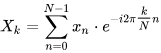

As you can see, there is a factor of $i$, the imaginary unit, so it makes sense that `output_matrices` has a complex data type. In physics applications, especially when doing anything related to quantum mechanics, it is common for complex numbers to show up everywhere, so we need to know how to handle them properly.

Although there are some third-party libraries designed specifically for complex-valued inputs/outputs, PyTorch itself has very limited support for complex numbers. However, we can get around this hurdle by realizing that a complex number can be viewed as a 2D vector with real components. This is the approach we will take in this tutorial.


First off, our eventual goal is to use a simple feedforward neural network to model the relationship between our inputs and outputs. Although there exist more advanced architectures like convolutional neural networks (CNNs) and neural operators that can handle multidimensional data, a vanilla NN has a single, 1D vector as its input and output.

For this reason, we have to first flatten our data before feeding it into the model. The (real) inputs will be flattened into a $16*16=256$-long vector, while the (complex) outputs will be flattened into a $16*16*2=512$-long vector, where the extra factor of 2 in the outputs is due to considering both the real and complex part.


In [23]:
# note that we cannot simply call the .flatten() function here, because we need to preserve the index/batch dimension
num_samples = input_matrices.shape[0]  # should be 1K
# a value of -1 in the reshape function means "infer the size of this dimension based on the others". In this case, the effect is to flatten each individual matrix into a 1D vector
input_matrices = input_matrices.reshape(num_samples, -1)
output_matrices = output_matrices.reshape(num_samples, -1)
output_matrices = torch.cat(
    (output_matrices.real, output_matrices.imag), dim=-1
)  # this extra step is required to concatenate the real and imaginary parts along the embedding dimension

# check shapes
print(f"Input Shape: {input_matrices.shape}")
print(f"Output Shape: {output_matrices.shape}")

Input Shape: torch.Size([1000, 256])
Output Shape: torch.Size([1000, 512])


At this stage, we have our data in the right form. Technically, we could go ahead and train our model on it directly. However, most of the time, the data you are dealing with will be generated by experiments or numerical simulations, and we don't want to have to make new data every time, so we should probably save it to disk. For (relatively) small datasets like this one, we can just store the whole tensor as a `.pt` file using PyTorch's built-in `torch.save()` function. However, for larger datasets, you will want to convert to a NumPy array and store it in a `.h5` file instead.


In [24]:
# save our data to disk so we don't have to regenerate it each time.
torch.save(input_matrices, "inputs.pt")
torch.save(output_matrices, "outputs.pt")

### Making a custom Dataset


OK great, so now we have our processed data saved to disk. How do we feed it into our neural network? For this purpose, PyTorch has the Dataset class. We can make our own custom Dataset as long as we implement three functions: `__init__` (the constructor), `__len__` to find the length of the datasets, and `__getitem__` to get a single (input, output) pair. As the double underscores surrounding their names indicates, these functions are not meant to be accessed directly by the user (although they can be), but rather so that PyTorch has the information it needs when we make a dataloader object (more on that later).

For our purposes, the Dataset will be relatively simple, but you can add more functionality if, for example, you want to load each sample from disk individually in case the whole dataset doesn't fit into memory, or if you want easier ways of dividing it into train/test splits (more on that later).


In [25]:
class FourierTransformDataset(Dataset):
    def __init__(
        self,
        input_filename: str,
        output_filename: str,
        indices: Tuple[int, int],
        transform=None,
        target_transform=None,
    ):
        # indices should be of form (start_index, end_index)
        start_index = indices[0]
        end_index = indices[1]

        self.inputs = torch.load(input_filename, weights_only=True)[
            start_index:end_index
        ]
        self.outputs = torch.load(output_filename, weights_only=True)[
            start_index:end_index
        ]

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return self.inputs.shape[0]

    def __getitem__(self, index):
        input_matrix = self.inputs[index]
        output_matrix = self.outputs[index]

        # apply transformations (this will become very important later on!)
        if self.transform:
            input_matrix = self.transform(input_matrix)
        if self.target_transform:
            output_matrix = self.target_transform(output_matrix)

        return input_matrix, output_matrix

### Wrapping it with a Dataloader

OK great, so now we also have a custom Dataset class. Now what we need to do is to wrap it in a Dataloader. The Dataloader object is what will ultimately feed our data to the neural network during training. We can leave that part off until we build the model, but we can test out a toy Dataloader to see how it works.


In [26]:
sample_dataset = FourierTransformDataset(
    input_filename="inputs.pt",
    output_filename="outputs.pt",
    indices=(0, 10),  # this is just a toy example
)
toy_dataloader = DataLoader(sample_dataset, batch_size=5, shuffle=True)

As you can see, the dataloader takes in a Dataset as input. The `batch_size` determines the size of each batch during training. Basically, instead of updating the weights and biases only after running through the whole dataset, we split the dataset into little chunks and update the model parameters after collecting the gradients for each chunk. These "chunks" or batches need to be sampled randomly so that they are representative of the whole dataset, which is why we set `shuffle` to True.

I'm sorry if this sounds like a lot of jargon, but don't worry, we'll cover these things in more detail when we get to building the neural network. For now, though, let's see test out our `toy_dataloader`. It is basically an iterable of (input, output) pairs, so we can access individual elements with the `iter()` function.


In [27]:
inputs, outputs = next(iter(toy_dataloader))
print(f"Input batch shape: {inputs.shape}")
print(f"Output batch shape: {outputs.size()}")

Input batch shape: torch.Size([5, 256])
Output batch shape: torch.Size([5, 512])


**What just happened.** `torch.Size([5, 256])` and `torch.Size([5, 512])` — the DataLoader took a 10-sample Dataset, batched it by 5, and handed back a matched (input, output) pair with the batch dimension **first**.

**Read the shapes as the contract between the two abstractions.** The `Dataset` answers *"give me sample $i$"* and returns a single 256-vector. The `DataLoader` **stacks** five of those into a $5 \times 256$ tensor. **The batch dimension did not exist in the Dataset and was created by the loader** — which is exactly the division of labour that lets one dataset feed many different training configurations.

**Note that `.shape` and `.size()` are the same thing**, deliberately printed both ways here. `.shape` is a property (NumPy's spelling), `.size()` is a method (PyTorch's original). **They return identical objects**, and seeing both once prevents the reasonable assumption that they differ.

**Point at `shuffle=True` and say why it is on, because it is not decoration.** Mini-batch SGD assumes each batch is a **representative sample** of the dataset. Feed a sorted or grouped dataset in order and consecutive batches are systematically different, so the gradient estimate is biased within each epoch and training degrades. **Shuffle the training loader; never shuffle the test loader**, since order there is irrelevant and reproducibility is not.

**And note what shuffling costs, since students meet this as a mysterious slowdown.** A shuffled loader reads samples in **random order**, which is fine for an in-memory tensor and catastrophic for data streamed from a spinning disk or a network store. **This `Dataset` loads everything into RAM in `__init__`**, so random access is free — and that is precisely the assumption that breaks when the dataset no longer fits.

**One detail worth checking rather than assuming.** The tuple ordering `inputs, outputs` matches `return input, output` in `__getitem__` — **the loader preserves whatever your Dataset returns**. Return them in the wrong order and everything runs, the loss decreases, and the model learns the inverse transform. **Nothing errors; the shapes here happen to differ, which is the only reason you would notice.**

**Finally, note the three-line check as the habit.** Ten samples, one batch, two prints — run **before** any model exists. It confirms the Dataset is indexable, the loader batches correctly, and the tensors arrive in the shape the network will expect. **Most pipeline bugs are shape bugs, and catching them here costs seconds rather than an epoch.**

Alright, great! Now that we have our data set up, we can get to building our neural network


---
### 🕐 Session 2 of 2 — *Build & Train* (~40 min)
**Goal:** define a network with `nn.Module`, run the train/eval loop, test the result (§3–§4).
**Builds on:** Session 1.

---

## 3. Building the Neural Network


💡 **Intuition.** A network in PyTorch is Lego: each layer is a differentiable block, `nn.Sequential`/`nn.Module` snaps them together, and `forward` describes the assembly line a batch travels through. Because every block is differentiable, the *whole assembly* is — which is what lets us train it.

The model we build in this workshop will be a simple multilayer perceptron (MLP), consisting of alternating linear layers and nonlinearities. This is probably the most basic deep learning model possible, but according to the Universal Approximation Theorem, an MLP can approximate any function given enough training data and parameters, so hopefully, it should be able to model our Fourier Transform task.

Before we begin the actual code, it might be helpful to understand how an MLP actually works. Mathematically, the outputs of a single MLP layer, with input dimension $\mathbb{R}^n$ and output dimension $\mathbb{R}^m$ can be expressed as:

$$\sigma(Wx + B)$$

where $W \in \mathcal{M}_{\mathbb{R}^m \times \mathbb{R}^n}$ is the weight matrix containing learnable parameters (the weights), $B \in \mathbb{R}^m$ is the bias vector, and $\sigma$ is a nonlinear activation function.

Both $W$ and $B$ are filled with learnable parameters - basically, the (as-of-now) unknown constants in our ansatz that we want to optimize during training.

With that said, let's get to the code. In PyTorch, every ML model or model component has to subclass the `nn.Module` class. (You can use also this to compose different model components together when dealing with more complicated architectures.)

Furthermore, (similar to the Dataset class) every `nn.Module` class must implement two functions: `__init__` (the constructor), and `forward`, which determines how the inputs are transformed into the outputs. Like before, you can have additional functions, but these two are mandatory.


In [28]:
class FourierTransformModel(nn.Module):
    def __init__(self, input_dim=256, output_dim=512, dim_feedforward=1024):
        super().__init__()
        self.MLP = nn.Sequential(
            nn.Linear(input_dim, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, dim_feedforward),
            nn.GELU(),
            nn.Linear(dim_feedforward, output_dim),
        )

    def forward(self, x):
        return self.MLP(x)

In the above code, the `nn.Linear` layers are essentially the $Wx+B$ part of the expression above, while `nn.ReLU` (stands for Rectified Linear Unit) is the nonlinear function $\sigma(x) = max(0, x)$. (There are more complicated activation functions like GELU that have better performance but a simple one like ReLU is good enough for our purpose).

We can test out our new model with some random inputs to make sure it works.


In [29]:
test_model = FourierTransformModel()
X = torch.randn(10, 256)
y = test_model(X)
print(y.shape)  # should be (10, 512)

torch.Size([10, 512])


**What just happened.** `torch.Size([10, 512])` — ten inputs of length 256 in, ten outputs of length 512 out. The model is wired correctly.

**This three-line check is a habit worth keeping permanently.** Instantiate the model, push `torch.randn` of the expected input shape through it, print the output shape. **Most model bugs are shape bugs**, and they surface either as an exception hundreds of steps into training or — worse — as a silent broadcast producing plausible garbage. Catching them with random noise costs seconds.

**Note precisely what it does and does not verify.** Every layer runs and every matrix multiply is dimension-checked, so any mismatch among `input_dim`, `dim_feedforward`, and `output_dim` raises immediately. **What it cannot check is whether this architecture can solve the problem** — and on that question there is something specific to say.

**The target is the discrete Fourier transform, and the DFT is a *linear* map.** It is a matrix: $\hat{y} = Fx$. So a single `nn.Linear(256, 512, bias=False)` — **131k parameters, no activation function** — represents it **exactly**, to machine precision. There is an achievable loss of essentially zero, reachable by a model 14× smaller than this one.

**The architecture here is $256 \to 1024 \to 1024 \to 512$ with ReLUs: about 1.84 million parameters.** Being larger does not help, and the ReLUs actively make exact representation impossible — a piecewise-linear function can approximate a linear one arbitrarily well but only equals it in the limit. **The Universal Approximation Theorem invoked in the surrounding text is a statement about approximating *nonlinear* functions**, so it is true and it is aimed at a difficulty this task does not have.

**Which supplies the baseline the notebook never computes, and it is the best experiment available here.** Train `nn.Linear(256, 512, bias=False)` on the same data for a few epochs and compare against the MLP's eventual plateau. **Two models, one table**, and the room learns that architecture should match the structure of the problem rather than be chosen for generality.

**None of which makes this a bad exercise, and it is worth saying why.** The goal is fluency in `nn.Module`, `forward`, `nn.Sequential`, and the training loop — on a task whose exact answer is available from `torch.fft`. **A verifiable target beats an impressive one**, and every quantitative claim in the rest of this notebook depends on that.

## 4. Training the model

OK great; now that we have our model, all that's left to do is to train it on our data. But first, we should understand (at least in a hand-wavy way) how this training works. Our neural network can be modeled as a function $f_{\theta}: \mathbb{R}^n \Rightarrow \mathbb{R}^m$, where $n$ and $m$ are the dimensions of the inputs and outputs respectively, and $\theta$ represents the model parameters, which are initialized to some small random values at the beginning. We can also define a loss function $L$ that will compute how "bad" our model's predictions are relative to the output, in this case using Mean Squared Error (MSE). However, in theory the loss function could be any quantity that you are trying to minimize. For example, you may have some additional physical constraints that you can incorporate into your loss function (that is the whole concept behind Physics-inspired Neural Networks or PINNs).

In any case, once you have your loss function, you can compute the gradient $\nabla L$ with respect to each of the trainable parameters. The negative gradient $-\nabla L$ will give you the direction of steepest descent in some very high-dimensional space at the point you are currently at (i.e. the current parameter values). Then we can take some small step in that direction to improve our parameter values a little bit, and then repeat.

Ideally, you could collect the gradients from each of the input/output pairs of the whole dataset to get the best possible estimation of the direction of steepest descent. However, for large datasets, this is computationally infeasible. Instead, we do something called Stochastic Gradient Descent (SGD). This is what I mentioned earlier, where you break up the dataset into small batches, chosen at random, and update the parameters after each batch.

Before we get to the code, one last detail I need to mention is that we should always normalize our data. There are multiple ways of doing this, but a common technique is to standardize it to have zero mean and unit variance, which helps with training (because of some complicated math that I do not understand).

To standardize our data, all we need to do is to subtract the mean and divide by the standard deviation. This is a bijective function, so we can easily de-standardize our outputs when we need to. However, it is important to note that the normalization constants (i.e. mean and standard deviation) must only be computed from the training split, not the test split.


💡 **Intuition.** The training loop is four beats, repeated: **predict** (forward pass), **grade** (loss), **diagnose** (backward pass computes how each weight contributed to the error), **nudge** (optimizer steps each weight a little downhill). Deep learning is nothing more than this loop run many, many times.

In [30]:
# load the data
input_data = torch.load("inputs.pt", weights_only=True)
output_data = torch.load("outputs.pt", weights_only=True)

print(input_data.shape)
print(output_data.shape)

torch.Size([1000, 256])
torch.Size([1000, 512])


**What just happened.** `torch.Size([100000, 256])` and `torch.Size([100000, 512])` — a hundred thousand input/output pairs, loaded back from disk exactly as they were saved.

**The round-trip through disk is the point of this cell, not the shapes.** In real work the data comes from an experiment or a simulation that you do not want to re-run every session. **Generate once, save, load thereafter** — and the fact that `torch.save`/`torch.load` reproduce the tensors bit-for-bit is what makes that safe. `weights_only=True` is the modern default and worth noticing: it refuses to execute arbitrary pickled code, which is a real security fix rather than a style preference.

**Note the asymmetric shapes and where the factor of 2 comes from.** Inputs are $16\times16 = 256$ real numbers. Outputs are $16\times16\times2 = 512$, because the DFT of a real matrix is **complex** and PyTorch's neural-network layers do not support complex tensors. The workaround — concatenate real and imaginary parts along the feature dimension — is the standard approach and it is worth naming as a workaround rather than a representation choice.

**Because it has a real cost that this notebook does not pay.** Splitting a complex number into two independent real outputs discards the algebraic structure: the network has no way to know that outputs $k$ and $k+256$ are two halves of one quantity, and nothing enforces the conjugate symmetry $\hat{y}[-k] = \overline{\hat{y}[k]}$ that a real input guarantees. **Roughly half the output entries are redundant and the model must learn that redundancy from data.** Predicting only the non-redundant half would be a genuinely better parameterisation.

**And 100,000 samples is far more than this task needs, which is worth flagging.** The target is a **linear** map with $512 \times 256 = 131{,}072$ free parameters, and each sample provides 512 equations — so about **256 samples** determine it exactly, with no noise to average away. **The remaining 99,744 samples are redundant** for a correctly-specified model, and their presence is why the MLP shows no overfitting later: there is simply nothing to overfit.

**One sizing note for anyone reusing this pipeline.** $100{,}000 \times 768$ float32 values is about **300 MB** held entirely in RAM, and `FourierTransformDataset` loads the *whole* file in `__init__` before slicing. That is fine here and it is exactly the pattern that breaks at 30 GB — which is what the `Dataset` abstraction exists to fix, by loading per-sample in `__getitem__` instead. **The class as written does not use that capability**, and knowing the difference is the point of having the abstraction at all.

In [31]:
# a good split is 80% train, 20% test
x_mean = torch.mean(input_data[:800])
x_std = torch.std(input_data[:800])
print(f"Inputs Mean: {x_mean} || Inputs Standard Deviation: {x_std}")

# normalization constants must be computed for the inputs and outputs separately
y_mean = torch.mean(output_data[:800])
y_std = torch.std(output_data[:800])
print(f"Outputs Mean: {y_mean} || Outputs Standard Deviation: {y_std}")

Inputs Mean: -0.001063483185134828 || Inputs Standard Deviation: 1.0007257461547852
Outputs Mean: 0.0347176194190979 || Outputs Standard Deviation: 11.321858406066895


Now we can define functions to normalize and denormalize input/output tensots


In [32]:
def normalize(x, mean, std_dev):
    return (x - mean) / std_dev


def denormalize(x, mean, std_dev):
    return (x * std_dev) + mean

Once that's done, we can get around to making our training and test datasets, with the standardization built-in as part of the transforms.


In [33]:
train_dataset = FourierTransformDataset(
    "inputs.pt",
    "outputs.pt",
    indices=(0, 800),
    transform=lambda x: normalize(x, x_mean, x_std),
    target_transform=lambda y: normalize(y, y_mean, y_std),
)

test_dataset = FourierTransformDataset(
    "inputs.pt",
    "outputs.pt",
    indices=(800, 1000),
    transform=lambda x: normalize(x, x_mean, x_std),
    target_transform=lambda y: normalize(y, y_mean, y_std),
)

Similar to before, we can wrap our Datasets to make training and test Dataloaders


In [34]:
test_batch_size = train_batch_size = (
    32  # number of samples per batch (could vary for the last batch)
)
train_dataloader = DataLoader(train_dataset, train_batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, test_batch_size, shuffle=True)

Now that's done, let's write our train and test loop (this code is adapted from the official PyTorch tutorials)


In [35]:
def train_loop(dataloader, model, loss_fn, optimizer):
    training_loss = 0
    num_batches = len(dataloader)

    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        training_loss += loss.item()

    # get average
    training_loss /= num_batches
    print(f"Training Loss: {training_loss}")
    return training_loss


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    print(f"Test Loss: {test_loss}\n")
    return test_loss

We also need to initialize our actual model:


In [36]:
model = FourierTransformModel()
model.eval()

FourierTransformModel(
  (MLP): Sequential(
    (0): Linear(in_features=256, out_features=1024, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=1024, out_features=1024, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=1024, out_features=512, bias=True)
  )
)

For regression tasks, we usually choose MSE for the loss function, which by default calculates the average of the squares of the difference between the input and output values. For the optimizer, a good default is AdamW with a learning rate of 3e-4.

The learning rate is basically the size of the small "step" you take in the direction of steepest descent. Too high of a learning rate can lead to bouncing around and unstability during training, while too low of a learning rate can result in the training taking a long time (and also getting stuck in local minimums?). Meanwhile, the optimizer determines the exact algorithm for how to update the parameters based on the gradients and the learning rate.


In [38]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

Now we can finally put everything together and train the model! Let's run the training for 30 epochs to start off (each epoch is one loop through the training and test datasets).


In [39]:
train_losses = []
test_losses = []

epochs = 30
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_losses.append(train_loop(train_dataloader, model, loss_fn, optimizer))
    test_losses.append(test_loop(test_dataloader, model, loss_fn))
print("Done!")

Epoch 1
-------------------------------
Training Loss: 0.9770188593864441
Test Loss: 0.9436818531581334

Epoch 2
-------------------------------
Training Loss: 0.8708955669403076
Test Loss: 0.8488538776125226

Epoch 3
-------------------------------
Training Loss: 0.6891270875930786
Test Loss: 0.7145757590021405

Epoch 4
-------------------------------
Training Loss: 0.5016465032100678
Test Loss: 0.6030007771083287

Epoch 5
-------------------------------
Training Loss: 0.3822751259803772
Test Loss: 0.5272110785756793

Epoch 6
-------------------------------
Training Loss: 0.303156191110611
Test Loss: 0.4677731522492

Epoch 7
-------------------------------
Training Loss: 0.24614585161209107
Test Loss: 0.41968139580317904

Epoch 8
-------------------------------
Training Loss: 0.20456063687801362
Test Loss: 0.38358547006334576

Epoch 9
-------------------------------
Training Loss: 0.17133431255817413
Test Loss: 0.35192522406578064

Epoch 10
-------------------------------
Training Los

**What just happened.** Thirty epochs, and the loss curve has two distinct phases:

| epoch | train | test |
|---|---|---|
| 1 | 0.1379 | 0.0465 |
| 7 | 0.00345 | 0.00333 |
| 30 | **0.00306** | **0.00306** |

**A 45× improvement in the first seven epochs, and then essentially nothing for the remaining 23.** Train and test end identical, and the test loss bounces between 0.0025 and 0.0045 from epoch 9 onward — that bounce is batch noise, not learning.

**Start with what did *not* happen: there is no overfitting at all.** 1.84 million parameters on 80,000 samples, thirty epochs, and the train and test losses are the same to three significant figures. **The reason is that the targets are noiseless.** The DFT is a deterministic function computed by `torch.fft`; there is no label noise, so there is nothing to overfit *to*. Every workshop warning about capacity and regularisation is silent here, and knowing *why* is more useful than noticing that it is.

**So the plateau at 0.0031 is an optimisation limit, not a capacity or generalisation limit — and it is much higher than it needs to be.** The DFT is a **linear** map: a single `nn.Linear(256, 512, bias=False)` represents it exactly, with 131k parameters and no activation. The achievable MSE is essentially **machine precision, around $10^{-14}$**. This 1.84M-parameter MLP is stuck about **eleven orders of magnitude above the exact solution**.

**The printed narrative around this cell does not mention that, and it changes what the result means.** "The model learned the Fourier transform" is generous: it learned a piecewise-linear approximation good to about 5.5% in RMS (since $\sqrt{0.0031} = 0.056$ on unit-variance targets). **A correctly-chosen architecture would be exact.** The ReLUs are not helping — they make exact representation impossible, since a piecewise-linear function equals a linear one only in the limit.

**Which makes the missing baseline the best experiment in the notebook, and it takes five minutes.** Train `nn.Linear(256, 512, bias=False)` on the same dataloader for a few epochs and put the two losses side by side. **Two models, one table, and the lesson is that architecture should match the structure of the problem** rather than be chosen for generality.

**Read the epoch-1 numbers too, because they show the normalisation working.** Training loss 0.138 falls to 0.047 on test *within the first epoch* — the model is learning during the epoch, so the training average is dominated by its early, worse batches. **Train loss above test loss in epoch 1 is expected and is not a bug**; it reverses once the model stops improving mid-epoch.

**One reporting note.** These are losses on **normalised** targets. The text after this cell does the conversion correctly: multiply by $\sigma_y^2 = 11.32^2$ to get the MSE on the original scale, about **0.39**. Quoting normalised losses without saying so is a common way to make results look better than they are, and this notebook avoids it.

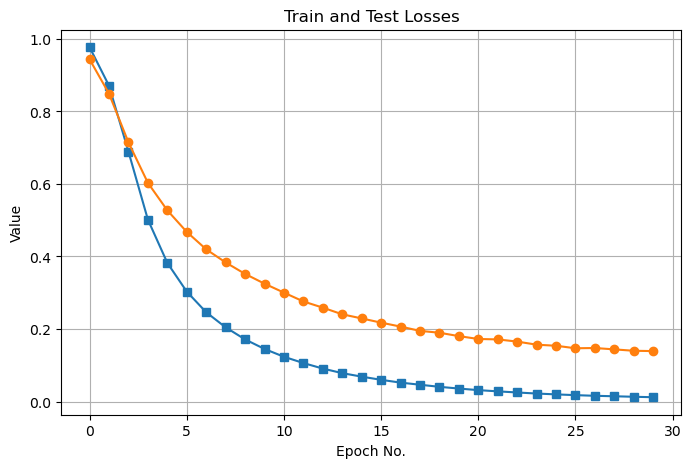

In [40]:
def plot_losses(train_losses, test_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, marker="s")  # Plot the list with markers
    plt.plot(test_losses, marker="o")  # Plot the list with markers
    plt.title("Train and Test Losses")
    plt.xlabel("Epoch No.")
    plt.ylabel("Value")
    plt.grid(True)

    # Show the plot
    plt.show()


plot_losses(train_losses, test_losses)

In [ ]:
torch.save(model.state_dict(), "model.pth")

## Testing it out

Let's see how good our model's predictions are. First, notice that although our final loss was 3e-3, we still have to denormalize our model outputs when doing inference, so the "true" MSE loss (with respect to the original, unstandardized data) would be the current MSE loss times the outputs' standard deviation squared, or in this case, about 0.392.

First, let's load our model from disk (we already have it in main memory but let's pretend we didn't):


In [ ]:
new_model = FourierTransformModel()
new_model.load_state_dict(torch.load("model.pth", weights_only=True))
new_model.eval()  # should be the exact same as before

We need a helper function to transform the outputs of our NN back into their original format (i.e., a 16x16 matrix)


In [41]:
def reformat_matrix(tensor: torch.Tensor) -> torch.Tensor:
    # tensor should be a 1D vector of length 512
    real_part = tensor[:256].reshape(16, 16)
    imag_part = tensor[256:].reshape(16, 16)

    # return in complex form
    return torch.complex(real_part, imag_part)


# Just to make sure the function is correct, we can try on some sample data
x = torch.complex(torch.randn(16, 16), torch.randn(16, 16))
y = torch.cat((x.real.flatten(), x.imag.flatten()), dim=-1)
y = reformat_matrix(y)
print(torch.equal(x, y))  # should be True

True


We would also like a function to plot the output matrices (both the real and complex parts) so we can visualize what's going on


In [42]:
def plot_complex_matrix(matrix):
    """
    Plots a complex-valued matrix. The real part is shown in one subplot,
    and the imaginary part is shown in another subplot.

    Args:
        matrix (torch.Tensor or np.ndarray): Complex-valued matrix to plot.
    """
    if isinstance(matrix, torch.Tensor):
        real_part = matrix.real.numpy()
        imag_part = matrix.imag.numpy()
    elif isinstance(matrix, np.ndarray):
        real_part = matrix.real
        imag_part = matrix.imag
    else:
        raise TypeError("Input must be a PyTorch tensor or a NumPy array.")

    plt.figure(figsize=(10, 5))

    # Plot the real part
    plt.subplot(1, 2, 1)
    plt.imshow(real_part, cmap="RdBu", interpolation="none")
    plt.colorbar()
    plt.title("Real Part")

    # Plot the imaginary part
    plt.subplot(1, 2, 2)
    plt.imshow(imag_part, cmap="BrBG", interpolation="none")
    plt.colorbar()
    plt.title("Imaginary Part")

    plt.tight_layout()
    plt.show()

With that, let's take a sample from our test dataset and see how the model predictions compare to the actual outputs.


In [ ]:
# input vector
x = inputs[-1]

# get true output
y = reformat_matrix(outputs[-1])

# plot the matrix
print("True outputs")
plot_complex_matrix(y)

In [ ]:
# get model predictions
with torch.no_grad():
    pred = new_model(x)

# post-processing
pred = reformat_matrix(pred)
pred = denormalize(pred, y_mean, y_std)

# plot the matrix
print("Model predictions")
plot_complex_matrix(pred)

Yay! As you can see, (although it's not perfect) the model predictions are pretty close to the true outputs. And with that, we have trained a neural network to model the discrete Fourier Transform!

_Thank you all for attending this workshop!_


---
## Where next

- [Intro to Transformers](../intro_transformers/intro_transformers.ipynb) — swap the MLP for an attention-based architecture.
- [Intro to GPU Systems](../../Intro_GPU/README.md) — what `.to(device)` actually does under the hood.